# Прогностическая модель рисков беременных

## Описание данных:


**Age**: Возраст женщины на момент беременности

**SystolicBP**: систолическое АД. Верхнее значение артериального давление (мм рт.ст.)

**DiastolicBP**: нижнее значение диастолического давления (мм. рт.ст)

**BS**: уровень глюкозы в крови (ммоль/л).

**BodyTemp**: (температура тела) у беременных

**HeartRate**: частота сердечных сокращений в покое.

**Risk Level**: таргет. Прогнозируемый уровень интенсивности риска во время беременности


## Загрузка библиотек и данных

In [1]:
!pip install phik -q
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.4 MB/s eta 0:00:00


In [2]:
import os
import warnings
from sklearn.exceptions import ConvergenceWarning
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
from phik.report import correlation_report, plot_correlation_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_predict
from catboost import CatBoostClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, GridSearchCV

In [3]:
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [4]:
RANDOM_STATE = 42

In [5]:
url = "https://drive.google.com/uc?id=1--FeiK0Yo4GARky8s3OjujnXgOeicO1V"
df_risk = pd.read_csv(url)

In [6]:
df_risk.head(5)

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


## Предобработка данных

Переводим названия столбцов в Snake case

In [7]:
def snake_columns(df):
    """
    Приводит названия столбцов к snake_case:
    """
    df.columns = (df.columns
          .str.strip()
          .str.replace('ё', 'e')
          .str.replace(r'(.)([A-Z][a-z]+)', r'\1_\2', regex=True)
          .str.replace(r'([a-z0-9])([A-Z])', r'\1_\2', regex=True)
          .str.replace(' ', '_').str.lower())
    return df

In [8]:
df_risk = snake_columns(df_risk)

In [9]:
df_risk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           1014 non-null   int64  
 1   systolic_bp   1014 non-null   int64  
 2   diastolic_bp  1014 non-null   int64  
 3   bs            1014 non-null   float64
 4   body_temp     1014 non-null   float64
 5   heart_rate    1014 non-null   int64  
 6   risk_level    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


Пропусков нет и типы данных в порядке

In [10]:
df_risk.isna().sum()

,0
age,0
systolic_bp,0
diastolic_bp,0
bs,0
body_temp,0
heart_rate,0
risk_level,0


**Проверка на полные дубликаты и разночтения**

In [11]:
df_risk.risk_level.unique()

array(['high risk', 'low risk', 'mid risk'], dtype=object)

Разночтений нет

In [12]:
int(df_risk.duplicated().sum())

562

В данных обнаружено 562 полностью дублирующихся строки, что составляет более половины выборки. Это структурная особенность данных, а не единичная ошибка. Это указывает на высокую степень повторяемости наблюдений и требует дополнительной проверки источника данных и логики формирования датасета.

Реальных уникальных строк ≈ 452

Возможные причины (для медицинского датасета):

- данные агрегированы / синтетические
- много шаблонных записей
- данные округлены по всем фичам
- возможно это повторяющиеся комбинации типовых случаев (т.к. у нас нет уникального id для пациента)

In [13]:
df_agg = df_risk.value_counts().reset_index(name='count')
df_agg.head(15)

,age,systolic_bp,diastolic_bp,bs,body_temp,heart_rate,risk_level,count
0,19,120,80,7.0,98.0,70,mid risk,27
1,48,120,80,11.0,98.0,88,high risk,14
2,31,120,60,6.1,98.0,76,mid risk,13
3,40,160,100,19.0,98.0,77,high risk,10
4,55,140,95,19.0,98.0,77,high risk,10
5,32,140,90,18.0,98.0,88,high risk,9
6,54,140,100,15.0,98.0,66,high risk,9
7,32,120,90,7.5,98.0,70,low risk,7
8,40,120,95,11.0,98.0,80,high risk,7
9,31,120,60,6.1,98.0,76,low risk,7


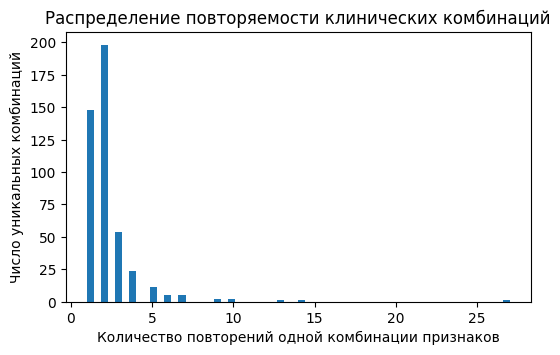

In [14]:
plt.figure(figsize=(6, 3.5))
plt.hist(df_agg['count'], bins=60)
plt.xlabel('Количество повторений одной комбинации признаков')
plt.ylabel('Число уникальных комбинаций')
plt.title('Распределение повторяемости клинических комбинаций')
plt.show()

Можем сделать вывод, что скорее всего наши данные синтетические. Потому что в реальных медицинских данных совпадение 2-3 показателей - это нормально, но совпадение всех 7 одновременно десятки раз - крайне маловероятно, тем более в категории среднего и высокого риска, а не клинической нормы. Значения выглядят округленными, а температура почти всегда 98 - не похоже на шумные измерения.

По гистограмме мы видим что большинство комбинаций встречаются 1-2 раза,реже 3. Но есть уникальные комбинации, продублированные 13,14 и 27 раз

**Как работать с дублями**

Несмотря на то,что данные скорее всего синтетические будем воспринимать дубликаты как не случайные,а идентичные клинические профили.Мы не можем удалить дубликаты как "ошибки", потому что так мы потеряем информацию о частоте состояний и модель не будет видеть какие профили встречаются чаще - сместится распределение классов.

Можно агрегировать данные по уникальным комбинациям,и испрользовать частоту встречаемости как вес. При этом датасет стоит разделить на трейн и валидацию после агрегации со стратификацией по риску,чтобы не было утечки (повторяющихся комбинаций) в трейне и тесте. Нам нужно смоделировапть сценарий, чтобы у модели была хорошая обощающая способность и она могла корректно оценить риск для других, ранее не встречавшихся профилей.


## EDA

### Описательная статистика

Описательную статистику будем смотреть на неагрегированном датасете,потому что в модели весом будем учитывать частотность случаев.

In [15]:
df_risk.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1014.0,29.871795,13.474386,10.0,19.0,26.0,39.0,70.0
systolic_bp,1014.0,113.198225,18.403913,70.0,100.0,120.0,120.0,160.0
diastolic_bp,1014.0,76.460552,13.885796,49.0,65.0,80.0,90.0,100.0
bs,1014.0,8.725986,3.293532,6.0,6.9,7.5,8.0,19.0
body_temp,1014.0,98.665089,1.371384,98.0,98.0,98.0,98.0,103.0
heart_rate,1014.0,74.301775,8.088702,7.0,70.0,76.0,80.0,90.0


**age** - стандартное отклонение не является чрезмерно большим; среднее и медианное значения различаются, но незначительно, что указывает на умеренную асимметрию распределения. В выборке присутствуют выбросы, однако они не носят экстремального характера. Минимальное и максимальное значения укладываются в пределы возможного человеческого возраста и не являются выбросами на порядок, однако выходят за рамки физиологической нормы беременности.

Беременность в возрасте около 70 лет является крайне маловероятным, но теоретически возможным исключительным случаем. В то же время беременность в 10 лет — медицински крайне редкое и клинически неблагоприятное состояние, связанное с высоким риском для здоровья и выходящее за пределы нормальных физиологических условий. Такие наблюдения не могут рассматриваться как нормальные значения возраста беременных пациенток.

Средний возраст пациенток в выборке составляет около 29 лет.

**systolic_bp**
Среднее значение систолического артериального давления составляет около 113 мм рт. ст., медиана - 120 мм рт. ст.; различие между ними незначительно, что указывает на отсутствие выраженной асимметрии распределения. Стандартное отклонение умеренное (≈ 18 мм рт. ст.), что отражает клинически ожидаемую вариабельность показателя.

Нормальными считаются значения систолического артериального давления в диапазоне 90-120 мм рт. ст. В выборке присутствуют значения как ниже 90 мм рт. ст. (гипотония), так и выше 140 мм рт. ст. (клинически значимое повышение артериального давления). При этом все наблюдаемые значения укладываются в реалистичные физиологические пределы и не выглядят как технические ошибки.

В целом распределение показателя соответствует ожидаемым клиническим характеристикам популяции беременных пациенток.

**diastolic_bp** среднее значение диастолического артериального давления составляет около 76 мм рт. ст., медиана — 80 мм рт. ст. Различие между ними умеренное и не указывает на выраженную асимметрию распределения. Стандартное отклонение (≈ 14 мм рт. ст.) отражает клинически ожидаемую вариабельность показателя.

Нормальными считаются значения диастолического артериального давления в диапазоне 60–80 мм рт. ст. В выборке присутствуют значения ниже 60 мм рт. ст. (гипотония), а также значения выше 90 мм рт. ст., соответствующие клинически значимому повышению артериального давления. Все наблюдаемые значения находятся в реалистичных физиологических пределах и не свидетельствуют о наличии технических ошибок в данных.

**bs** (уровень глюкозы у беременных). Для беременных применяются более строгие пороги глюкозы натощак:

*Норма*: < 5.1 ммоль/л

*Допустимое повышение*: 5.1–6.9 ммоль/л

*Гестационный диабет (подозрение)*: ≥ 7.0 ммоль/л

*Выраженная гипергликемия*: ≥ 11.1 ммоль/л

Минимальное значение показателя в выборке составляет 6.0 ммоль/л, что превышает норму натощак. Это может указывать на то, что измерения проводились не натощак, либо выборка включает пациенток с повышенным метаболическим риском. В отсутствие информации об условиях измерения использование строгих диагностических порогов гестационного диабета ограничено. Тем не менее распределение показателя смещено в сторону повышенных значений и отражает клинически значимую вариабельность уровня глюкозы.

Если рассмотреть *постпрандиальные значения (после еды)*, то датасет лучше вписывается в них:

1 час после еды: до 7.8–8.0 ммоль/л — *норма*

2 часа после еды: до 6.7–7.0 ммоль/л — норма

*Критическое значение*: ≥ 11.1 ммоль/л

Таким образом, значения глюкозы в выборке находятся в пределах физиологически возможных значений для *случайных или постпрандиальных измерений*, однако часть наблюдений может требовать клинического внимания.

**body_temp** у нас в градусах Фаренгейта. Это нормально, но т.к. в нашей стране привычнее в градусах Цельсия, то логично перевести (будет нативно понятнее). Пока ориентировочный диапазон 98.6 °F — классическая "нормальная" температура тела
103 °F ≈ 39.4 °C — высокая, но реальная лихорадка. Стандартное отклонение небольшое (≈1.37 °F), что клинически ожидаемо.

**heart_rate**- норма ЧСС у беременных: ~70–90 уд/мин
(часто на 10–15 уд/мин выше, чем у небеременных). Брадикардия: < 60 уд/мин. Тахикардия: > 100 уд/мин. Минимальное ЧСС явный выброс (скорее всего опечатка,не дописали 0). При этом разница между медианным и средним небольшая - значит выброс одиночный. Основная масса наблюдений лежит в диапазоне 70–80 уд/мин, что соответствует физиологической норме для беременных.



In [16]:
#Переведем температуру в Цельсии для читаемости
df_risk['body_temp'] = (df_risk['body_temp'] - 32) / 1.8
df_agg['body_temp'] = (df_agg['body_temp'] - 32) / 1.8

### Смотрим распределения

In [17]:
def plot_numeric_features(df):
    """
    Строим для каждого числового признака:
    - гистограмму с KDE
    - боксплот с усами и аннотациями медианы, Q1 и Q3
    """
    numeric_cols = df.select_dtypes(include=['float', 'int'])

    for feature in numeric_cols:
        plt.figure(figsize=(9, 3.5))

        # Гистограмма
        plt.subplot(1, 2, 1)
        sns.histplot(df[feature].dropna(), bins=25, kde=True)
        plt.title(f'Распределение: {feature}')
        plt.xlabel(feature)
        plt.ylabel('Частота')
        plt.xticks(rotation=45)

        # Boxplot
        plt.subplot(1, 2, 2)
        sns.boxplot(x=df[feature], color='skyblue', fliersize=5)
        plt.title(f'Боксплот: {feature}', fontsize=14)
        plt.xlabel(feature)

        # Статистики
        q1 = df[feature].quantile(0.25)
        q3 = df[feature].quantile(0.75)
        median = df[feature].median()

        # Подписи
        y_max = plt.gca().get_ylim()[1]  # верх по оси Y боксплота
        plt.text(median, y_max*0.05, f'Медиана = {median:.1f}', ha='center', fontsize=10, color='orange')
        plt.text(q1, y_max*0.1, f'Q1 = {q1:.1f}', ha='center', fontsize=9, color='gray')
        plt.text(q3, y_max*0.1, f'Q3 = {q3:.1f}', ha='center', fontsize=9, color='gray')

        # Медиана линия
        plt.axvline(median, color='orange', linestyle='--')

        plt.tight_layout()
        plt.show()

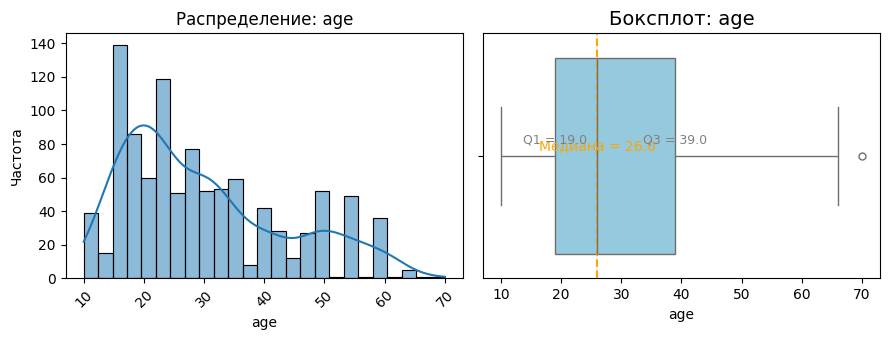

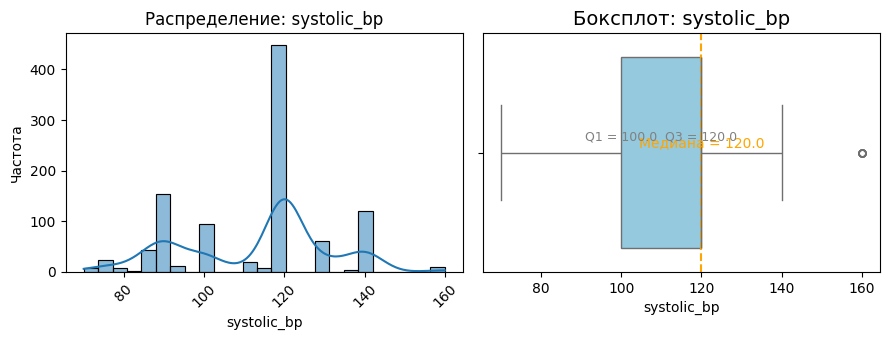

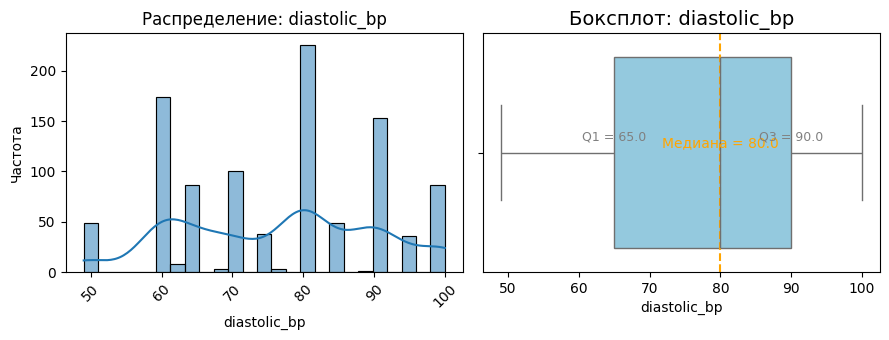

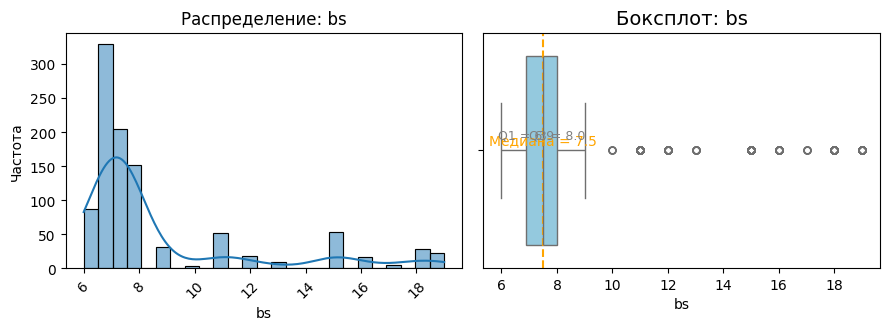

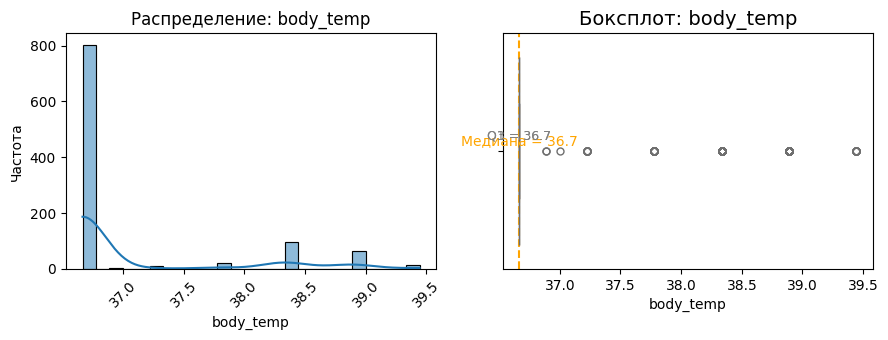

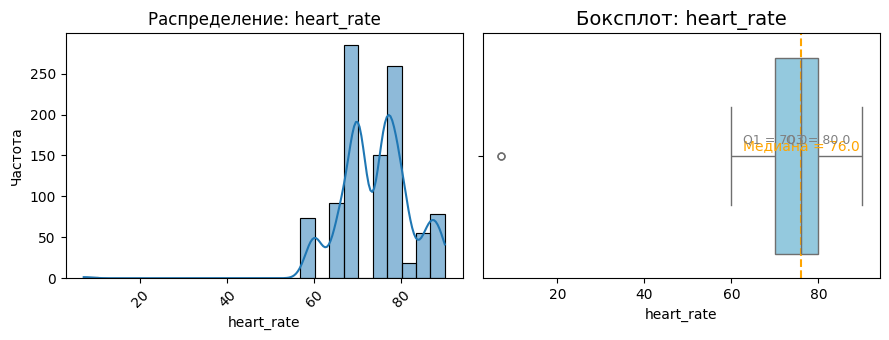

In [18]:
plot_numeric_features(df_risk)

In [19]:
df_risk.query('age<=18').age.value_counts()

,count
age,
17,63
15,60
12,35
18,19
16,16
13,12
10,4
14,3


In [20]:
print(f'Кол-во беременных в возрасте от 15 до 25 лет: {df_risk.query('age>=15 & age<25').age.count()}')
print(f'Кол-во беременных в возрасте от 20 до 30 лет: {df_risk.query('age>=20& age<30').age.count()}')

Кол-во беременных в возрасте от 15 до 25 лет: 404
Кол-во беременных в возрасте от 20 до 30 лет: 307


In [21]:
print(f'Кол-во беременных в возрасте от 40 до 50 лет: {df_risk.query('age>=40& age<50').age.count()}')
print(f'Кол-во беременных в возрасте от 50 до 60 лет: {df_risk.query('age>=50& age<60').age.count()}')

Кол-во беременных в возрасте от 40 до 50 лет: 114
Кол-во беременных в возрасте от 50 до 60 лет: 96


**age**

Довольно много случаев подростковой беременности (включая совсем ранний возраст 10-12 лет). Это не выброс,это клиническая картина. На боксплоте отмечается выброс в 70 лет,однако это тоже возможный кейс.
Распределение смещено влево,однако пик приходится на интервал 15-25 лет,вместо ожидаемых 20-30. Затем количество беременных снижается, при увеличении возраста. Интересно, что в интервале 50-60 лет суммарное количество беременных не намного меньше,чем в интервале 40-50 лет.

**systolic_bp** (систолическое артериальное давление)

Пик распределения приходится на 120 мм.рт.ст - клиническая норма. Выбивающаяся точка на боксплоте - 160 мм.рт.ст - возможное,но критическое состояние для беременной. Присутствуют беременные с гипотонией и гипертонией - ожидаемая вариабельность

**diastolic_bp** (диастолическое артериальное давление)

Имеет мультимодальное распределение. Основной пик распределения - 80 мм.рт.ст (совпадает с медианой) - клиническая норма. Однако есть дополнительные:в районе 60 и 90 мм.рт.ст.

Встречаются (не единичные) эктремельные с клинической точки зрения значения:
 - 50 мм рт. ст. (может быть гипотензия). Реально встречается у беременных с низким давлением, однако это острое нежелательное состояние. У беременной может снижаться кровоток к плаценте- потенциальный риск для плода и другие нежелательные явления. Для модели: информативный сигнал высокого риска
- 100 мм рт. ст. (почти гипертонический криз). Крайнее значение с высоким риском, опасно для матери и плода

In [22]:
print('разметка таргета у пациенток с подзрением на гипертонический криз:')
df_agg.query('diastolic_bp>=100').risk_level.head(10)

разметка таргета у пациенток с подзрением на гипертонический криз:


,risk_level
3,high risk
6,high risk
16,high risk
24,high risk
31,mid risk
36,high risk
38,high risk
49,high risk
64,high risk
67,high risk


Разметка адекватная

**bs** (уровень глюкозы у беременных)

распределение смещено влево, пик в районе 7 ммоль/л - клиническая норма для случайных измерений глюкозы (не натощак)
Встречаются экстремально высокие значения: случайные значения 16–19 ммоль/л постпрандиальной глюкозы могут быть реальными, но это критический сигнал, такие данные сразу относятся к высокому риску


In [23]:
print('таргет у пациенток с экремально высокой глюкозой:')
df_agg.query('bs>=15')[['bs','risk_level']].head(10)

таргет у пациенток с экремально высокой глюкозой:


,bs,risk_level
3,19.0,high risk
4,19.0,high risk
5,18.0,high risk
6,15.0,high risk
16,15.0,high risk
18,17.0,high risk
24,16.0,high risk
27,15.0,mid risk
30,15.0,high risk
31,16.0,mid risk


**Есть несоответствия разметки**. Пациенты с уровнем глюкозы 15 и 16 размечены как mid risk, в то время как этот параметр значительно выше критического порога, выраженная гипергликемия, соответствующая high risk.

Проверим сколько у нас таких сомнительных случаев

In [24]:

print(f'кол-во предположительно неправильно размеченных пациенток с завышенной глюкозой:{df_risk.query('(bs>=15) & (risk_level=="mid risk")').bs.count()}')


кол-во предположительно неправильно размеченных пациенток с завышенной глюкозой:18


Это примерно 1-2% выборки - редкие экстремумы. Модель в целом на них почти не будет влиять, если использовать стандартные веса

**body_temp**
Основной пик до 37 градусов Цельсия (~36.6), но есть и крайне высокие (но физиологически возможные) значения более 39°,которые не являются выбросом.


**heart_rate**

In [25]:
df_risk.query('heart_rate<50').head(5)

,age,systolic_bp,diastolic_bp,bs,body_temp,heart_rate,risk_level
499,16,120,75,7.9,36.666667,7,low risk
908,16,120,75,7.9,36.666667,7,low risk


У нас два дубликата с чсс 7 - явный выброс. Больше всего похоже на опечатку, т.к. таких строчек всего 2 исправим на 70.



In [26]:
df_risk.loc[df_risk['heart_rate'] == 7, 'heart_rate'] = 70
df_agg.loc[df_agg['heart_rate'] == 7, 'heart_rate'] = 70

Основные значения сконцентрированны в области клинической нормы: 65 до 80 уд/мин.Есть вариабельность,но она ожидаема

### Распределение классов в таргете

In [27]:
target_counts = df_risk['risk_level'].value_counts()

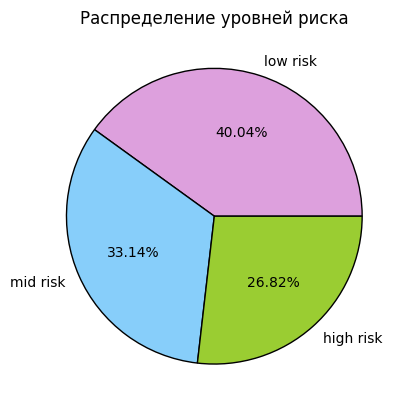

In [28]:
mycolors = ['plum', 'lightskyblue','yellowgreen']
plt.pie(target_counts.values,labels=target_counts.index, wedgeprops = { 'linewidth' : 1, 'edgecolor' : 'black'},colors =  mycolors, autopct='%.2f%%')
plt.title('Распределение уровней риска')
plt.show()

Мы видим что у большей части пациенток (40%) низкий уровень риска. Одеа пациенток со средним и высоким уровнем тоже немало (33,1 и 26,8 % соответственно). В нашем датасете нет ярко выраженного дисбаланса классов.

## Корреляционный анализ

У нас все фичи числовые, а таргет ординальный. Посмотрим взаимосвязь между числовыми признаками, посчитаем корреляцию **Spearman** на неагрегированном датасете

In [29]:
num_col = df_risk.select_dtypes(include='number').columns.tolist()

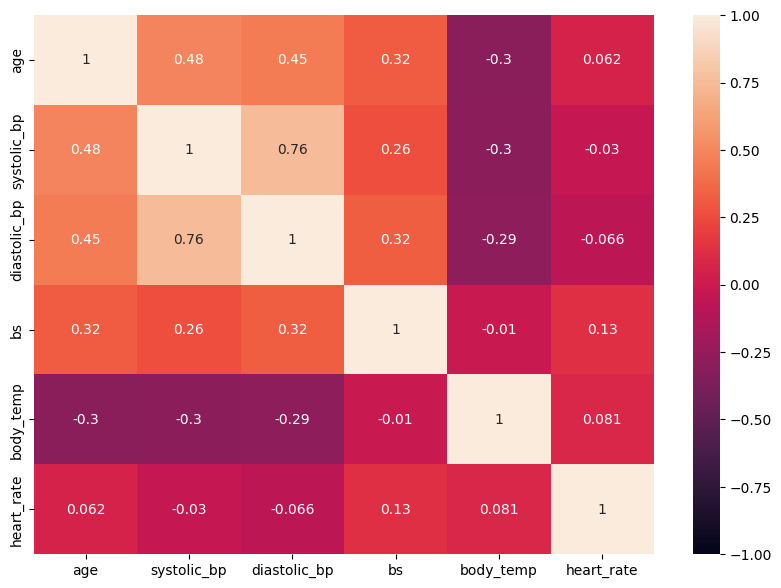

In [30]:
fig, ax = plt.subplots(figsize=(10,7))
_ = sns.heatmap(df_risk[num_col].corr(method='spearman'),vmin=-1, vmax=1, annot=True, ax=ax)

Есть хорошая зависимость между систолическим и диастолическим давлениями. Остальные взаимосвязи между признаками выглядят довольно слабыми, мультиколлинеарности нет.

In [31]:
risk_map = {'low risk': 0, 'mid risk': 1, 'high risk': 2}
df_risk_corr = df_risk.copy()
df_risk_corr['risk_level'] = df_risk['risk_level'].map(risk_map)

In [32]:
df_risk_corr.corr(method='spearman')['risk_level']

,risk_level
age,0.289031
systolic_bp,0.398284
diastolic_bp,0.319186
bs,0.445289
body_temp,0.166797
heart_rate,0.183996
risk_level,1.000000


При рассчете коэффициента Спирмена с закодированным таргетом самая высокая зависимость у blood sugar (уровень глюкозы), далее по значимости систолическое и диастолическое давления

Phik посмотрим в качестве доп.анализа, но в нем не учитывается ординальность таргета.

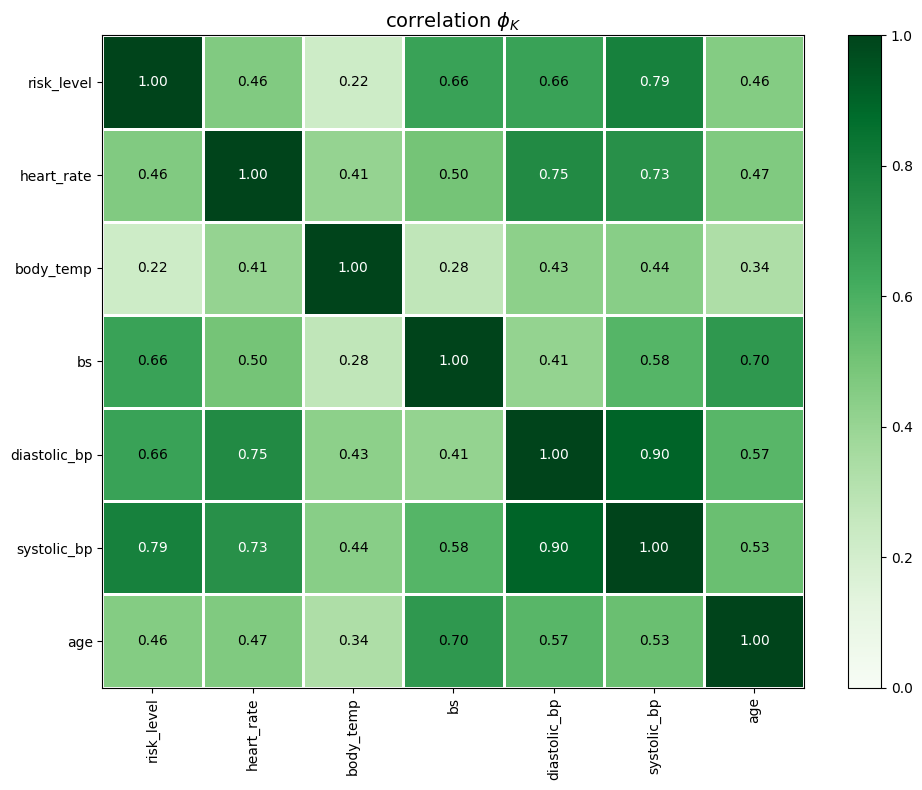

In [33]:
phik_overview = df_risk.phik_matrix(interval_cols = num_col)

plot_correlation_matrix(phik_overview.values,
                        x_labels=phik_overview.columns,
                        y_labels=phik_overview.index,
                        vmin=0, vmax=1, color_map="Greens",
                        title=r"correlation $\phi_K$",
                        fontsize_factor=1,
                        figsize=(10, 8))
plt.tight_layout()

**Отношения между фичами**: мы получили довольно высокую взаимосвязь систолического и диастолического давления, давлений и сердечного ритма, возраста и глюкозы. Звучит логично.

**Ключевые фичи для таргета**: систолическое,диастолическое давления,уровень глюкозы.

## Подготовка датасета

Выделяем выборки train и test из агрегированного датасета - так мы защищаем тест от утечки. Разделим со стратификацией,хоть и дисбаланс совсем небольшой

In [34]:
def split_data(df, target_col='risk_level', weight_col='count', test_size=0.25, random_state=RANDOM_STATE):
    """
    Разделяет df на X_train, X_test, y_train, y_test, w_train, w_test.
    """
    X = df.drop(columns=[target_col, weight_col])
    y = df[target_col]
    w = df[weight_col]

    X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
        X, y, w,test_size=test_size,stratify=y,random_state=random_state)

    return X_train, X_test, y_train, y_test, w_train, w_test

In [35]:
X_train, X_test, y_train, y_test, w_train, w_test = split_data(df_agg)

## Baseline model

В качестве базлайна возьмем Logistic Regression (multinomial), потому что она довольно простая,устойчивая,дегко интерпретируемая, умеет работать с мультиклассом и поддерживает sample_weight.
Т.к. у нас ординальный таргет multinomial - хороший выбор: обучается одна модель, которая оптимизируется общей softmax функцией и классы ранжируются относительно друг друга. Для базлайна мы не будем маштабтровать признаки. Это позволяет сохранить клинический смысл абсолютных значений показателей (АД, глюкоза, ЧСС) и избежать искусственного выравнивания их вклада.
Масштабирование использовалось только на этапе экспериментов и сравнения моделей.

In [36]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

y_pred_cv = np.empty_like(y_train, dtype=object)

for train_idx, val_idx in cv.split(X_train, y_train):
    X_tr, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr = y_train.iloc[train_idx]
    w_tr = w_train.iloc[train_idx]

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(multi_class='multinomial',
            solver='lbfgs',
            max_iter=1000,
            random_state=RANDOM_STATE))])

    #  обучение с весами
    pipe.fit(X_tr, y_tr, lr__sample_weight=w_tr)

    y_pred_fold = pipe.predict(X_val_fold)
    y_pred_cv[val_idx] = y_pred_fold

# метрики по CV
print("Classification report (CV) с масштабированием:")
print(classification_report(y_train, y_pred_cv, sample_weight=w_train))

print("Confusion matrix (CV) с масштабированием:")
print(confusion_matrix(y_train, y_pred_cv, sample_weight=w_train))

Classification report (CV) с масштабированием:
              precision    recall  f1-score   support

   high risk       0.76      0.67      0.71     205.0
    low risk       0.64      0.77      0.70     305.0
    mid risk       0.42      0.35      0.39     251.0

    accuracy                           0.61     761.0
   macro avg       0.61      0.60      0.60     761.0
weighted avg       0.60      0.61      0.60     761.0

Confusion matrix (CV) с масштабированием:
[[137  11  57]
 [  4 236  65]
 [ 39 123  89]]


**Общая оценка**

**Accuracy ≈ 0.65** - не высокая, но нормально для медицинской задачи, мультикласса

**Macro F1 ≈ 0.65** - модель не "любит" только один класс. Классы обрабатываются более-менее симметрично

Похоже на здоровый baseline, не шум и не leakage.

**high risk**:


**Precision 0.83** - в 83% предсказания high risk модель права
(мало ложных тревог — хорошо для врачей)

**Recall 0.66** 34% high risk пациенток пропущены. Это очень много, но для baseline — ожидаемо. Надо улучшать

**f1 = 0.73**

Recall high risk важнее precision

**low risk:**
precision = 0.66
recall    = 0.80

Модель хорошо отсекает здоровых, но немного переоценивает low risk - нормально для baseline,постараемся улучшить.

Самая слабая зона - **mid risk** (и это ожидаемо, т.к. размытый клинический класс.)Часто пересекается с low и граничит с high, даже в практике врачи не всегда сходятся во мнении по таким кейсам.

precision = 0.51
recall    = 0.46

Модель не путает high risk и low risk массово, иначе precision high risk был бы ниже, recall low risk был бы ниже. Можем принять такой базлайн

## Перебор моделей с гиперпараметрами

F1 macro выбираем как основную метрику для подбора модели.Для клиники важно не игнорировать средний класс mid risk, macro F1 лучше отражает качество модели для всех уровней риска.

Переберем гридсерчем гиперпараметры у катбуста с учетом весов и сделаем CV с ручным предсказанием, для того чтобы вывести classification report и confusion matrix на кросс-валидации

In [37]:
param_grid = {'depth': [4, 6, 8, 10],
    'learning_rate': [0.02, 0.03, 0.04],
    'iterations': [100, 150, 200, 500]}

model_cb = CatBoostClassifier(
    loss_function='MultiClass',
    random_seed=RANDOM_STATE,
    verbose=0)

search = GridSearchCV(estimator=model_cb,
    param_grid=param_grid,
    cv=cv,
    scoring='f1_macro',
    verbose=1,
    n_jobs=-1)

search.fit(X_train, y_train, sample_weight=w_train)
print("Лучшие параметры:", search.best_params_)
print("Лучший Macro F1 на CV:", search.best_score_)
best_model = search.best_estimator_.copy()

y_pred_cv = np.empty_like(y_train, dtype=object)  # создаём пустой 1D массив

for train_idx, val_idx in cv.split(X_train, y_train):
    X_tr, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr = y_train.iloc[train_idx]
    w_tr = w_train.iloc[train_idx]

    model = best_model
    model.fit(X_tr, y_tr, sample_weight=w_tr)

    y_pred_fold = model.predict(X_val_fold).ravel()
    y_pred_cv[val_idx] = y_pred_fold


print("Classification report (CV):")
print(classification_report(y_train, y_pred_cv, sample_weight=w_train))

print("Confusion matrix (CV):")
print(confusion_matrix(y_train, y_pred_cv, sample_weight=w_train))

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Лучшие параметры: {'depth': 8, 'iterations': 100, 'learning_rate': 0.04}
Лучший Macro F1 на CV: 0.6510830086914746
Classification report (CV):
              precision    recall  f1-score   support

   high risk       0.81      0.82      0.82     205.0
    low risk       0.65      0.87      0.74     305.0
    mid risk       0.57      0.32      0.41     251.0

    accuracy                           0.68     761.0
   macro avg       0.68      0.67      0.66     761.0
weighted avg       0.67      0.68      0.65     761.0

Confusion matrix (CV):
[[169  13  23]
 [  0 266  39]
 [ 39 131  81]]


**Mid risk** сильно путается с low risk (131) и high risk (39).

**Low risk** почти не путается с high risk, но часть идет в mid risk (39).

**High risk** относительно чистый, но есть небольшие ошибки.

## Feature engineering

In [38]:
df_agg1 = df_agg.copy()

In [39]:
# Добавили фичи. Хотим более явно показать высокий риск
# df_agg1['pulse_pressure'] = (df_agg['systolic_bp'] - df_agg['diastolic_bp'])
df_agg1['hypertension'] = (df_agg['systolic_bp'] >= 140).astype(int)
df_agg1['hyperglycemia'] = (df_agg['bs'] >= 7.8).astype(int)

In [40]:
X_train1, X_test1, y_train1, y_test1, w_train1, w_test1 = split_data(df_agg1)

In [41]:
best_cb_model = search.best_estimator_.copy()

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

y_pred_cv = np.empty_like(y_train1, dtype=object)

for train_idx, val_idx in cv.split(X_train1, y_train1):
    X_tr, X_val_fold = X_train1.iloc[train_idx], X_train1.iloc[val_idx]
    y_tr, y_val_fold = y_train1.iloc[train_idx], y_train1.iloc[val_idx]
    w_tr = w_train1.iloc[train_idx]

    model = best_cb_model.copy()
    model.fit(X_tr, y_tr, sample_weight=w_tr)


    y_pred_fold = model.predict(X_val_fold).ravel()
    y_pred_cv[val_idx] = y_pred_fold

print("Classification report (CV) на новых данных:")
print(classification_report(y_train1, y_pred_cv, sample_weight=w_train1))

print("Confusion matrix (CV) на новых данных:")
print(confusion_matrix(y_train1, y_pred_cv, sample_weight=w_train1))

Classification report (CV) на новых данных:
              precision    recall  f1-score   support

   high risk       0.78      0.84      0.81     205.0
    low risk       0.64      0.84      0.73     305.0
    mid risk       0.53      0.29      0.37     251.0

    accuracy                           0.66     761.0
   macro avg       0.65      0.66      0.63     761.0
weighted avg       0.64      0.66      0.63     761.0

Confusion matrix (CV) на новых данных:
[[172  14  19]
 [  2 257  46]
 [ 47 132  72]]


Стало хуже,фичи не помогли. Продолжим работу с первым (просто агрегированным, без доп.фич) датасетом

## Зададим пороги для классов.

Мы хотим, чтобы модель надежно распознавала высокий риск и неплохо средний. Низкий риск нас беспокоит в данном случае меньше - лучше ложное срабатывание, чем упустить важное. Поэтому зададим пороги вероятности так, чтобы модель чаще присваивала высокий и средний класс,при меньшей вероятности. Считать будем с кросс-валидацией. В качестве модели возьмем наш катбуст с подобранными гиперпараметрами

In [42]:
classes = best_model.classes_
idx_high = np.where(classes == 'high risk')[0][0]
idx_mid  = np.where(classes == 'mid risk')[0][0]

threshold = 0.4

y_pred_cv = np.empty_like(y_train, dtype=object)

for train_idx, val_idx in cv.split(X_train, y_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    w_tr, w_val = w_train.iloc[train_idx], w_train.iloc[val_idx]

    model = best_model.copy()
    model.fit(X_tr, y_tr, sample_weight=w_tr)

    y_proba_val = model.predict_proba(X_val)

    y_pred_fold = []
    for p in y_proba_val:
        if p[idx_high] >= threshold:
            y_pred_fold.append('high risk')
        elif p[idx_mid] >= threshold:
            y_pred_fold.append('mid risk')
        else:
            y_pred_fold.append('low risk')
    y_pred_cv[val_idx] = y_pred_fold

Выведем метрики на кросс-валидации

In [43]:
print("Classification report (CV с порогом):")
print(classification_report(y_train, y_pred_cv, sample_weight=w_train))

print("Confusion matrix (CV с порогом):")
print(confusion_matrix(y_train, y_pred_cv, sample_weight=w_train))

Classification report (CV с порогом):
              precision    recall  f1-score   support

   high risk       0.82      0.79      0.81     205.0
    low risk       0.61      0.80      0.70     305.0
    mid risk       0.49      0.32      0.39     251.0

    accuracy                           0.64     761.0
   macro avg       0.64      0.64      0.63     761.0
weighted avg       0.63      0.64      0.62     761.0

Confusion matrix (CV с порогом):
[[162  20  23]
 [  0 245  60]
 [ 35 135  81]]


Сравниваем метрики с лучшей моделью катбуста (без доп.фич)

**High risk**:

*Без порога*: recall 0.82, precision 0.81 - F1 0.82

*С порогом*: recall 0.79, precision 0.82 - F1 0.81

 без порога чуть выше чувствительность (recall), с порогом — чуть лучше точность.

**Mid risk**

*Без порога*: recall 0.32, precision 0.57 - F1 0.41

*С порогом*: recall 0.32, precision 0.49 - F1 0.39

ложных mid стало чуть больше.

**Low risk**

*Без порога*: recall 0.87, precision 0.65 - F1 0.74

*С порогом*: recall 0.80, precision 0.61 - F1 0.70


Вывод:
Модель с порогом отрабатывает хуже чем без.

Пороги нам тоже не помогли и мид класс по-прежнему плохо отделим. Можно попробовать сделать 2 шаговую модель (вместо одной трехклассовой):
1) первой моделью отфильровать без риска против mid+hight(задача не пропустить ни одного риска)
2) для тех кого модель сочла не low раделяем mid/hight

## 2 шаговая с CV

1 шаг - делаем бинарный таргет, разделяем на low и не low

In [44]:
y_pred_cv = np.empty_like(y_train, dtype=object)

for train_idx, val_idx in cv.split(X_train, y_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    w_tr, w_val = w_train.iloc[train_idx], w_train.iloc[val_idx]

    # шаг 1. Делаем бинарный таргет, разделяем на low и не low
    y_tr_step1 = (y_tr != 'low risk').astype(int)
    model_step1 = CatBoostClassifier(loss_function='Logloss',
                                     random_seed=RANDOM_STATE,
                                     verbose=0)
    model_step1.fit(X_tr, y_tr_step1, sample_weight=w_tr)
    proba_step1 = model_step1.predict_proba(X_val)[:, 1]

    # зададим порог для 1 шага. Чтобы вероятнее не пропустить случаи с риском
    thr_step1 = 0.4
    risk_mask = proba_step1 >= thr_step1

    # шаг 3: разделяем mid и high (train сет)
    mask_tr_step2 = y_tr != 'low risk'
    X_tr_step2 = X_tr[mask_tr_step2]
    y_tr_step2 = (y_tr[mask_tr_step2] == 'high risk').astype(int)
    w_tr_step2 = w_tr[mask_tr_step2]

    model_step2 = CatBoostClassifier(loss_function='Logloss',
                                     random_seed=RANDOM_STATE,
                                     verbose=0)
    model_step2.fit(X_tr_step2, y_tr_step2, sample_weight=w_tr_step2)

    # прогноз для val сета, который risk
    X_val_step2 = X_val[risk_mask]
    proba_step2 = model_step2.predict_proba(X_val_step2)[:, 1]

    # собираем предсказания
    y_val_pred = np.array(['low risk'] * len(X_val), dtype=object)
    y_val_pred[risk_mask] = 'mid risk'

    thr_step2 = 0.5
    risk_indices = np.where(risk_mask)[0]
    high_mask = proba_step2 >= thr_step2
    y_val_pred[risk_indices[high_mask]] = 'high risk'

    # сохранили в общий массив
    y_pred_cv[val_idx] = y_val_pred


In [45]:
print("Classification report (2 шаговая с CV):")
print(classification_report(y_train, y_pred_cv, sample_weight=w_train))

print("Confusion matrix (2 шаговая с CV):")
display(confusion_matrix(y_train, y_pred_cv, sample_weight=w_train))

Classification report (2 шаговая с CV):
              precision    recall  f1-score   support

   high risk       0.80      0.79      0.79     205.0
    low risk       0.66      0.69      0.67     305.0
    mid risk       0.45      0.43      0.44     251.0

    accuracy                           0.63     761.0
   macro avg       0.63      0.63      0.63     761.0
weighted avg       0.63      0.63      0.63     761.0

Confusion matrix (2 шаговая с CV):


array([[161,   6,  38],
       [  2, 211,  92],
       [ 39, 105, 107]])

Аналогично считаем на тесте

In [46]:
# Шаг 1: low и остальное
y_train_step1 = (y_train != 'low risk').astype(int)
model_step1 = CatBoostClassifier(loss_function='Logloss',
                                 random_seed=RANDOM_STATE,
                                 verbose=0)
model_step1.fit(X_train, y_train_step1, sample_weight=w_train)

# Предсказанные вероятности для теста
proba_step1_test = model_step1.predict_proba(X_test)[:, 1]

# Порог шаг 1
thr_step1 = 0.4
risk_mask_test = proba_step1_test >= thr_step1

# Шаг 2:разделяем mid и high
mask_train_step2 = y_train != 'low risk'
X_train_step2 = X_train[mask_train_step2]
y_train_step2 = (y_train[mask_train_step2] == 'high risk').astype(int)
w_train_step2 = w_train[mask_train_step2]

model_step2 = CatBoostClassifier(loss_function='Logloss',
                                 random_seed=RANDOM_STATE,
                                 verbose=0)
model_step2.fit(X_train_step2, y_train_step2, sample_weight=w_train_step2)

# Шаг 2: предикт на тесте (которые относятся к части risk)
X_test_step2 = X_test[risk_mask_test]
proba_step2_test = model_step2.predict_proba(X_test_step2)[:, 1]

# Собираем финальные предсказания
y_pred_test = np.array(['low risk'] * len(X_test), dtype=object)
y_pred_test[risk_mask_test] = 'mid risk'

thr_step2 = 0.5
risk_indices_test = np.where(risk_mask_test)[0]
high_mask_test = proba_step2_test >= thr_step2
y_pred_test[risk_indices_test[high_mask_test]] = 'high risk'


In [47]:
print("Classification report (2 шаговая, test):")
print(classification_report(y_test, y_pred_test, sample_weight=w_test))


Classification report (2 шаговая, test):
              precision    recall  f1-score   support

   high risk       0.79      0.79      0.79      67.0
    low risk       0.65      0.65      0.65     101.0
    mid risk       0.49      0.48      0.49      85.0

    accuracy                           0.63     253.0
   macro avg       0.64      0.64      0.64     253.0
weighted avg       0.63      0.63      0.63     253.0



In [48]:
classes

array(['high risk', 'low risk', 'mid risk'], dtype=object)

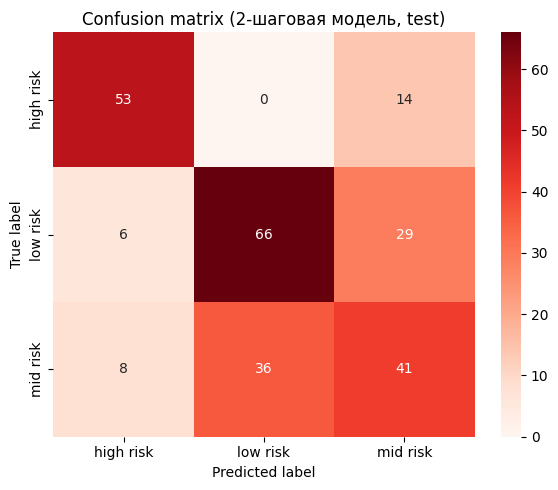

In [49]:
cm = confusion_matrix(y_test, y_pred_test, sample_weight=w_test, labels=classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm,
    annot=True,
    fmt='.0f',
    cmap='Reds',
    xticklabels=classes,
    yticklabels=classes)

plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion matrix (2-шаговая модель, test)')
plt.tight_layout()
plt.show()


True **high risk**
всего 67

53 - правильно предсказали high

0  high - low (критической ошибки нет)

14 - high - mid (мягкая ошибка)

Модель не занижает высокий риск до low. Если ошибается — отправляет в mid, что безопаснее.

True **low risk**

66 - правильно low

6  low в high (переоценка риска)

29  low в mid

Модель иногда перестраховывается, но это допустимо медицински.

True **mid risk**
 всего 85
41 - правильно mid

36  mid в low (занизили средний риск)

8  mid в high

Основная проблема модели — путаница mid в low, а не high. Это не очень хорошо

2 шаговая модель на тесте:

хорошо удерживает high risk,  улучшает mid recall (по сравнению в одношаговой мультиклассификацией), low recall падает, но это ожидаемо.

**Вывод для применения**:

Если в задаче критично не пропустить средний и высокий риск, 2 шаговая более выигрышная стратегия.

Если приоритет — максимальная точность по low/high, лучше 1 шаговая.

## Итоговый вывод по проекту

В рамках проекта была решена задача мультиклассовой классификации уровня риска беременности (low / mid / high risk) на агрегированном датасете, где повторяющиеся наблюдения были учтены через веса (count). Основной целью являлось построение модели, которая не только показывает хорошие метрики, но и минимизирует критические ошибки, прежде всего - занижение высокого риска.

В ходе работы была выполнена:
- **загрузка библиотек и данных**
- **предобработка данных** ( перевод названий столбцов в snake_case, оценка пропусков и типов данных, проверка на дубликаты и разночтения. В ходе проверки оказалось, что полных дубликатов более 50% данных, поэтому данные были агрегированны и количество дубликатов учитывалось через веса при построении модели).
- проведен исследовательский анализ данных (**EDA**), включающий в себя описательную статистику и графическтй анализ (гстограммы, боксплоты, пайчарт). Данные были оценены на адекватность и соответствие клиническим нормам, устранены выбросы, исследовано распределение классов в таргете.

*Примечание*:
**data curation**. Исправили в двух строках значение heart_rate с 7 на 70 (предположили опечатку)

В ходе исследовательскго анализа были сформулированы следующие **вопросы**:

1) Как измерялся уровень глюкозы (натощак,случайное измерение,постпрандиальные значения)

2) Уточнить правильность разметки: пациенты с уровнем глюкозы (предположительно постпрандиальной (после еды) 15 и 16 размечены как mid risk, в то время как этот параметр значительно выше критического порога, выраженная гипергликемия, соответствующая high risk.

3) Уточнить возраст беременных (10 и 70 лет)- реальные ли это клинические случаи

4) Более 50% данных полные дубликаты, необходима дополнительная проверка источника данных и логики формирования датасета.

- проведен **корреляционный анализ**

Корреляция Спирмена показала хорошую зависимость между систолическим и диастолическим давлениями. При рассчете коэффициента Спирмена с закодированным таргетом самая высокая зависимость у blood sugar (уровень глюкозы), далее по значимости систолическое и диастолическое давления. Также дополнительно оценили phik корреляцию

- **подготовка датасета** для ML. Агрегированный датасет разделили на тренировочку и тестовую выборки. Валидационную выделять не стали,т.к. оценивали метрики через кросс-валидацию.

- **baseline**

В качестве базлайна взяли Logistic Regression (multinomial).
Для базлайна мы не маштабировали признаки(только на этапе экспериментов и сравнения моделей,практически не влияло) - это позволяет сохранить клинический смысл абсолютных значений показателей (АД, глюкоза, ЧСС).

Модель хорошо отсекала здоровых, но переоценивала low risk.
Самая слабая зона - mid risk.

- в качестве основной модели взяли **CatBoost** с подбором гиперпараметров ('depth': 8, 'iterations': 100, 'learning_rate': 0.04) на cv как одну из моделей, поддерживающих веса (count). Однако в будущем хотелось бы сравнить с другими моделями, может есть более перспективные. Модель показала улучшение по сравнеию с базлайном.

- **Feature engineering**. Попробовали добавить новые фичи (pulse_pressure,hypertension,hyperglycemia) но они не внесли существенный вклад (и даже немного ухудшили) в обобщающую способность модели.

- попробовали улучшить разделение классов с помощью **порогов (threshold)**. Кросс-валидация показала ухудшение определения mid класса

- Собрали **2-шаговую модель**(иерархическую) с cv. Идея заключается в том,чтобы на первом шаге отделить low классы от классов с риском (mid и hight), а на втором разделить mid и hight.
Модель обучалась с учётом весов наблюдений и оценивалась как на CV, так и на тестовой выборке.

**Результаты:**
Macro F1 ≈ 0.63–0.64

Accuracy ≈ 0.63

Практически отсутствуют ошибки high - low

Ключевое наблюдение:
Двухшаговая модель не превосходит базовую по агрегированным метрикам,
но демонстрирует более интерпретируемую и безопасную структуру ошибок.

**Итоговый вывод**:
Если цель — максимальные метрики, предпочтительна базовая модель (катбуст с гиперпараметрами)

Если цель — безопасность и контроль ошибок, 2-шаговая модель выглядит более оправданной

**Что хотелось бы улучшить/сделать**

Перебрать другие модели/нейросеть.
Сделать валидацию,оценить качество модели (Shap и т.д.).
Можно посмотреть feature importance/permutation, однако у нас и так мало признаков, кажется что это не самая приоритетная задача